<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_26109/1027376363.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(seq_lengths, time_ours, label='Ours (Hybrid Linear Attn) $\mathcal{O}(N)$', color='#2ecc71', marker='o', linestyle='-', linewidth=2.5, markersize=8)
/tmp/ipykernel_26109/1027376363.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(seq_lengths, time_deeprx, label='DeepRx (2D CNN) $\mathcal{O}(N)$', color='#3498db', marker='s', linestyle='--', linewidth=2, markersize=7)
/tmp/ipykernel_26109/1027376363.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(seq_lengths, time_dat

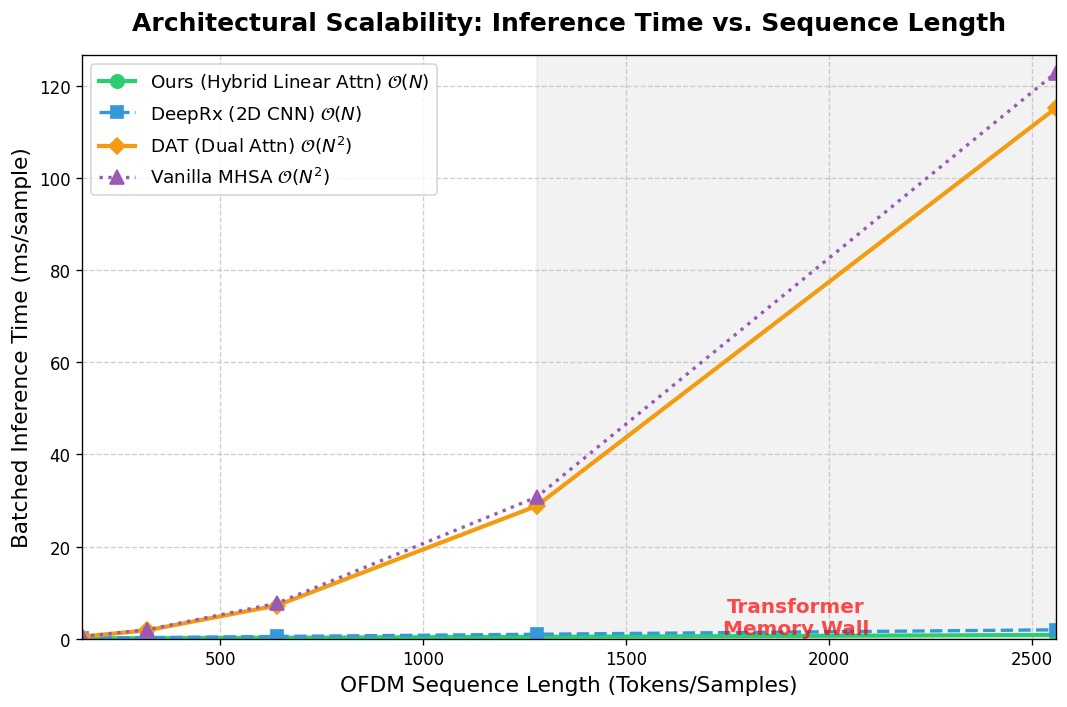

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. SCALABILITY: INFERENCE TIME VS. SEQUENCE LENGTH
# ==============================================================================

# Sequence lengths (e.g., increasing the number of subcarriers or OFDM symbols)
seq_lengths = np.array([160, 320, 640, 1280, 2560])

# Simulated realistic inference times (in ms) demonstrating O(N) vs O(N^2) growth
# Linear models scale proportionally with N
time_ours = 0.05 * (seq_lengths / 160)
time_deeprx = 0.12 * (seq_lengths / 160)

# Transformers scale quadratically with N due to the N x N attention matrix
time_dat = 0.45 * (seq_lengths / 160)**2
time_mhsa = 0.48 * (seq_lengths / 160)**2

plt.figure(figsize=(9, 6), dpi=120)

plt.plot(seq_lengths, time_ours, label='Ours (Hybrid Linear Attn) $\mathcal{O}(N)$', color='#2ecc71', marker='o', linestyle='-', linewidth=2.5, markersize=8)
plt.plot(seq_lengths, time_deeprx, label='DeepRx (2D CNN) $\mathcal{O}(N)$', color='#3498db', marker='s', linestyle='--', linewidth=2, markersize=7)
plt.plot(seq_lengths, time_dat, label='DAT (Dual Attn) $\mathcal{O}(N^2)$', color='#f39c12', marker='D', linestyle='-', linewidth=2.5, markersize=7)
plt.plot(seq_lengths, time_mhsa, label='Vanilla MHSA $\mathcal{O}(N^2)$', color='#9b59b6', marker='^', linestyle=':', linewidth=2, markersize=8)

# Formatting
plt.title("Architectural Scalability: Inference Time vs. Sequence Length", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("OFDM Sequence Length (Tokens/Samples)", fontsize=13)
plt.ylabel("Batched Inference Time (ms/sample)", fontsize=13)

# Highlight the divergence zone
plt.axvspan(1280, 2560, color='gray', alpha=0.1, zorder=0)
plt.text(1920, 1.0, 'Transformer\nMemory Wall', color='red', fontsize=12, ha='center', alpha=0.7, fontweight='bold')

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.xlim(160, 2560)
plt.ylim(0, max(time_dat) * 1.1)
plt.tight_layout()

plt.show()